In [43]:
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ultranest
from ultranest.plot import PredictionBand, cornerplot



In [44]:
urllib.request.urlretrieve(
    "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_summary.txt",
    "Land_and_Ocean_complete_annual.txt"
)
data = np.loadtxt("Land_and_Ocean_complete_annual.txt", comments="%")
print(data)

[[ 1.850e+03 -4.360e-01  1.700e-01 ...  1.560e-01        nan        nan]
 [ 1.851e+03 -3.210e-01  2.590e-01 ...  2.250e-01        nan        nan]
 [ 1.852e+03 -2.920e-01  2.490e-01 ...  2.170e-01 -3.160e-01  1.530e-01]
 ...
 [ 2.022e+03  9.360e-01  3.100e-02 ...  2.800e-02  9.580e-01  2.200e-02]
 [ 2.023e+03  1.229e+00  3.100e-02 ...  2.800e-02        nan        nan]
 [ 2.024e+03  1.311e+00  3.200e-02 ...  2.700e-02        nan        nan]]


In [45]:
columns = [
    "year",
    "annual_anomaly_above", "annual_unc_above",
    "five_year_anomaly_above", "five_year_unc_above",
    "annual_anomaly_below", "annual_unc_below",
    "five_year_anomaly_below", "five_year_unc_below",
]

df = pd.DataFrame(data, columns=columns)

dtype_map = {
    "year": "int",
    "annual_anomaly_above": "float",
    "annual_unc_above": "float",
    "five_year_anomaly_above": "float",
    "five_year_unc_above": "float",
    "annual_anomaly_below": "float",
    "annual_unc_below": "float",
    "five_year_anomaly_below": "float",
    "five_year_unc_below": "float",
}
df = df.astype(dtype_map)


print(df[:-5])

     year  annual_anomaly_above  annual_unc_above  five_year_anomaly_above  \
0    1850                -0.436             0.170                      NaN   
1    1851                -0.321             0.259                      NaN   
2    1852                -0.292             0.249                   -0.325   
3    1853                -0.295             0.196                   -0.294   
4    1854                -0.283             0.130                   -0.309   
..    ...                   ...               ...                      ...   
165  2015                 0.923             0.027                    0.885   
166  2016                 1.059             0.027                    0.922   
167  2017                 0.962             0.026                    0.971   
168  2018                 0.888             0.028                    0.996   
169  2019                 1.024             0.031                    0.964   

     five_year_unc_above  annual_anomaly_below  annual_unc_belo

In [46]:
yerr_above = df["annual_unc_above"] / 1.96
yerr_below = df["annual_unc_below"] / 1.96

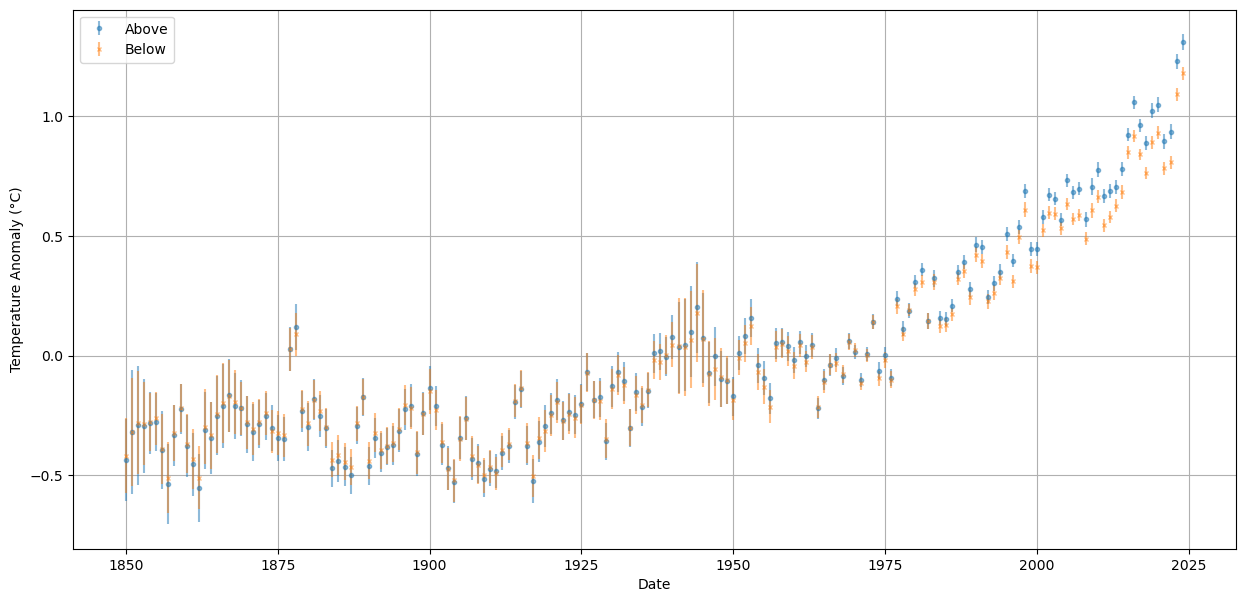

In [47]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)
plt.errorbar(df["year"], df["annual_anomaly_below"], yerr=df["annual_unc_below"], fmt="x", markersize=3, label="Below", alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [48]:
# convert to np arrays for easier ingestion for ultranest
date = df["year"].values
temp_anomaly = df["annual_anomaly_above"].values
sigma2 = yerr_above ** 2



In [49]:
def constant_model(q):
    return q 

def constant_prior(cube):
    params = cube.copy()

    lower_bound = -10.0
    upper_bound = 10.0

    params[0] = lower_bound + cube[0] * (upper_bound - lower_bound)

    return params

def log_likelihood(params):
    q = params[0]
    model = constant_model(q)

    residuals = temp_anomaly - model
    log_likelihood_value = -0.5 * np.sum(
        np.log(2 * np.pi * sigma2) + (residuals ** 2) / sigma2
    )

    return log_likelihood_value

parameters = ["q"]

In [50]:
sampler = ultranest.ReactiveNestedSampler(
    parameters, log_likelihood, constant_prior
)
result = sampler.run()
print(result)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-3e+04  -27553.70 [-27553.6983..-27553.6983]*| it/evals=4520/5069 eff=96.8087% N=400 0      
[ultranest] Likelihood function evaluations: 5076
[ultranest]   logZ = -2.756e+04 +- 0.1048
[ultranest] Effective samples strategy satisfied (ESS = 1238.5, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.11, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.10 tail:0.04 total:0.11 required:<0.50
[ultranest] done iterating.
{'niter': 4928, 'logz': np.float64(-27561.848998706184), 'logzerr': np.float64(0.25822159150790025), 'logz_bs': np.float64(-27561.833292122603), 'logz_single': np.float64(-27561.848998706184), 'logzerr_tail': np.float64(0.04120267244798015), 'logzerr_bs': np.float64(0.2549131815030705), 'ess': np.float64(1238.4717734815647), 'H': np.float64(7.6938159587589325), 'Herr': np.float64(0.09876329329328981), 'posterior': {'m

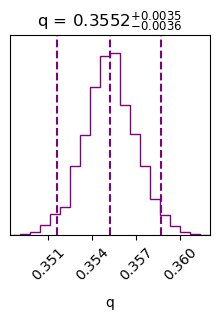

In [51]:
cornerplot(
    result,
    title_fmt=".4f",
    quantiles=[0.025, 0.5, 0.975]
)
plt.show()

In [52]:
print(result["posterior"])

{'mean': [0.3552140742528833], 'stdev': [0.0017519022344872005], 'median': [0.3551890609044328], 'errlo': [0.3536119245080462], 'errup': [0.3569718800307413], 'information_gain_bits': [4.14647919764959]}


In [53]:
print(result["samples"])

[[0.35583626]
 [0.35704816]
 [0.35400211]
 ...
 [0.35475166]
 [0.35519315]
 [0.3507671 ]]


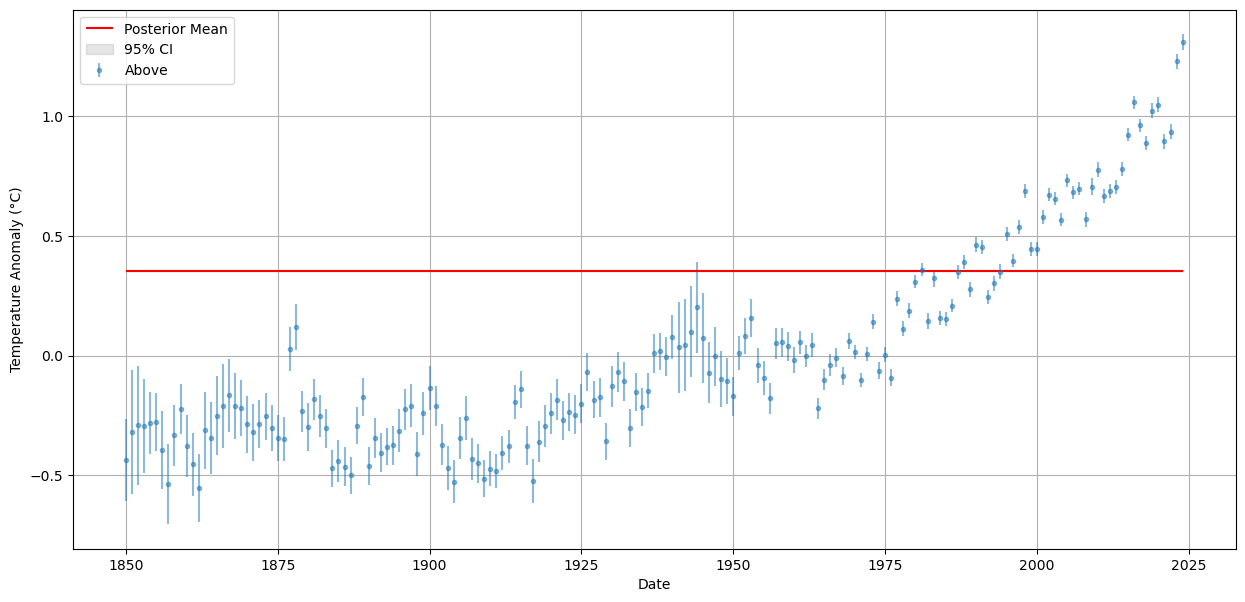

In [54]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)
plt.hlines(result["posterior"]["mean"], df["year"].min(), df["year"].max(), color="red", label="Posterior Mean")
q_samples = result["samples"][:, 0]
ci_low, ci_high = np.percentile(q_samples, [2.5, 97.5])

plt.fill_between(
    [df["year"].min(), df["year"].max()],
    ci_low,
    ci_high,
    color="gray",
    alpha=0.2,
    label="95% CI",
)
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [55]:
def linear_model(x, q, m):
    return q + m*x

def linear_prior(cube):
    params = cube.copy()

    lo_0 = -2000.0
    hi_0 = 2000.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -5.
    hi_1 = 5.
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    return params

def log_linear_likelihood(params):
    q = params[0]
    m = params[1]
    model = linear_model(date, q, m)
    residuals = temp_anomaly - model
    log_likelihood_value = -0.5 * np.sum(
        np.log(2 * np.pi * sigma2) + (residuals ** 2) / sigma2
    )

    return log_likelihood_value

parameters_linear = ["q", "m"]

In [56]:
sampler_linear = ultranest.ReactiveNestedSampler(
    parameters_linear, log_linear_likelihood, linear_prior
)
result_linear = sampler_linear.run()
print(result_linear)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-6e+03  203.68 [-6203.6888..-6203.6888]*| it/evals=12080/16487 eff=75.0917% N=400   0     0  0   
[ultranest] Likelihood function evaluations: 16503
[ultranest]   logZ = -6229 +- 0.2049
[ultranest] Effective samples strategy satisfied (ESS = 1616.5, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.21, need <0.5)
[ultranest]   logZ error budget: single: 0.25 bs:0.20 tail:0.01 total:0.21 required:<0.50
[ultranest] done iterating.
{'niter': 12495, 'logz': np.float64(-6229.314959228823), 'logzerr': np.float64(0.46477968742804837), 'logz_bs': np.float64(-6229.317885557839), 'logz_single': np.float64(-6229.314959228823), 'logzerr_tail': np.float64(0.009938688679540064), 'logzerr_bs': np.float64(0.4646734125308285), 'ess': np.float64(1616.4799544623647), 'H': np.float64(24.61955336752817), 'Herr': np.float64(0.20110963258834955), 'posterior': {'me

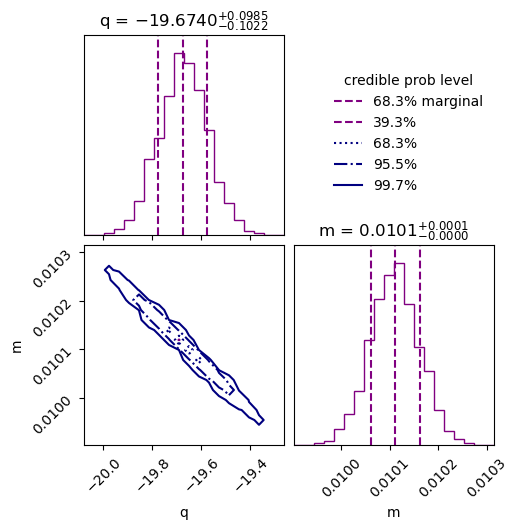

In [57]:
cornerplot(
    result_linear,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

In [58]:
print(result_linear["posterior"])
print(result_linear["samples"])

{'mean': [-19.673996998479048, 0.010110012260336308], 'stdev': [0.09904980005793985, 4.9979807538262744e-05], 'median': [-19.673649334644097, 0.010109766200515402], 'errlo': [-19.776214211586876, 0.010060696858770861], 'errup': [-19.57555928636566, 0.010162523713339814], 'information_gain_bits': [4.14647919764959, 4.14647919764959]}
[[-1.97609475e+01  1.01564168e-02]
 [-1.94665656e+01  1.00045913e-02]
 [-1.95559031e+01  1.00495697e-02]
 ...
 [-1.98755020e+01  1.02111897e-02]
 [-1.95658415e+01  1.00555000e-02]
 [-1.97825271e+01  1.01661685e-02]]


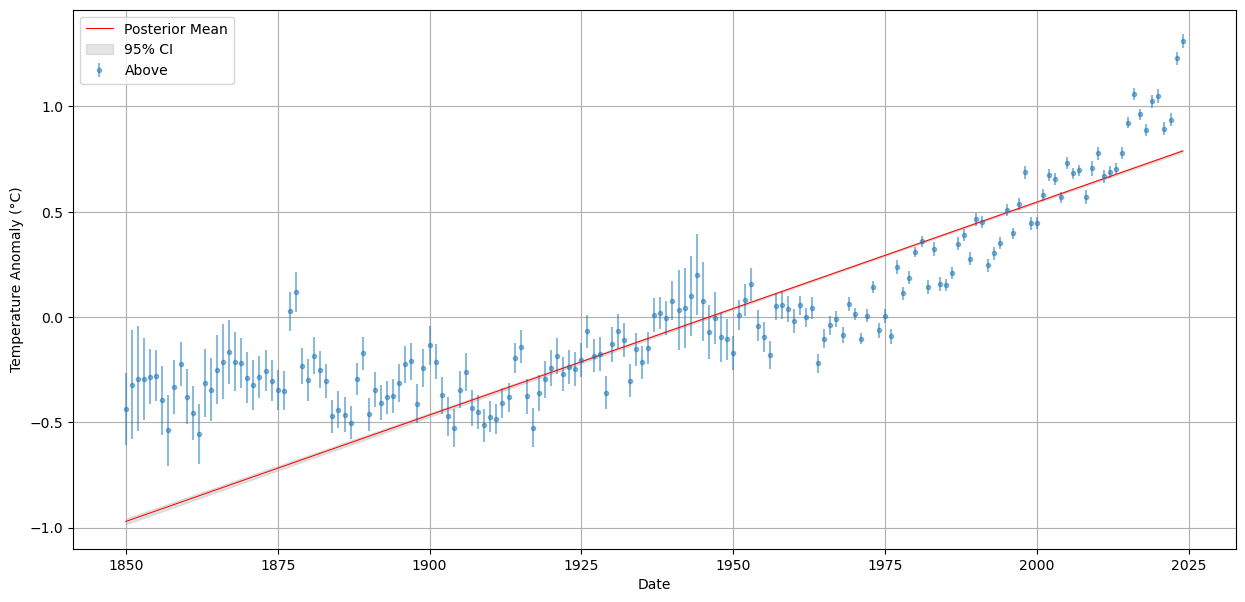

In [59]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min(), df["year"].max(), 100)
band = PredictionBand(year_range)

for params in result_linear["samples"]:
    q, m = params
    band.add(linear_model(year_range, q, m))

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.2)


plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [60]:
def exponential_model(x, q, a, m):
    # Rescale time to avoid overflow in exp for calendar-year inputs.
    t = (x - 1950.0) / 50.0
    #exponent = np.clip(m * t, -50.0, 50.0)
    return q + a * np.exp(m * t)


def exponential_prior(cube):
    params = cube.copy()

    lo_0 = -2.0
    hi_0 = 2.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -2.0
    hi_1 = 2.0
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    lo_2 = -4.0
    hi_2 = 4.0
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)

    return params


def log_exponential_likelihood(params):
    q, a, m = params
    model = exponential_model(date, q, a, m)

    if not np.all(np.isfinite(model)):
        return -1e300

    resid = temp_anomaly - model
    variance = np.asarray(yerr_above) ** 2

    if np.any(variance <= 0) or not np.all(np.isfinite(variance)):
        return -1e300

    residuals = temp_anomaly - model
    log_likelihood_value = -0.5 * np.sum(
        np.log(2 * np.pi * sigma2) + (residuals ** 2) / sigma2
    )

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value


parameters_exponential = ["q", "a", "m"]

In [61]:
sampler_exponential = ultranest.ReactiveNestedSampler(
    parameters_exponential, log_exponential_likelihood, exponential_prior
)
result_exponential = sampler_exponential.run()
print(result_exponential)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-1e+03  311.76 [-1311.8204..-1311.8203]*| it/evals=9520/37596 eff=25.5941% N=400    0  0 
[ultranest] Likelihood function evaluations: 37605
[ultranest]   logZ = -1331 +- 0.1463
[ultranest] Effective samples strategy satisfied (ESS = 1928.4, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.
{'niter': 9928, 'logz': np.float64(-1331.0094889196946), 'logzerr': np.float64(0.29799246602879165), 'logz_bs': np.float64(-1330.9987396932843), 'logz_single': np.float64(-1331.0094889196946), 'logzerr_tail': np.float64(0.009942845816794943), 'logzerr_bs': np.float64(0.29782654285168064), 'ess': np.float64(1928.4095765328923), 'H': np.float64(17.701615653916633), 'Herr': np.float64(0.13751948132543845), 'posterior': {'mean':

In [62]:
df_results = pd.DataFrame(result_exponential["samples"], columns=parameters_exponential)
df_results.describe()

,q,a,m
count,9928.000000,9928.000000,9928.000000
mean,-0.411046,0.303627,1.113955
std,0.007843,0.006855,0.013571
min,-0.439112,0.278085,1.065335
25%,-0.416079,0.298979,1.104726
50%,-0.411147,0.303547,1.113922
75%,-0.405569,0.308171,1.123146
max,-0.382856,0.330019,1.167726


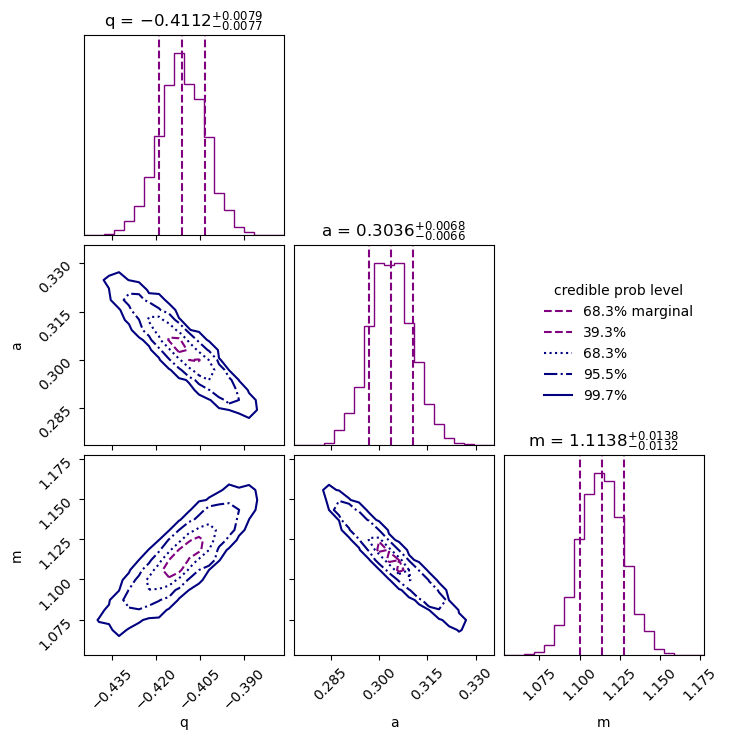

In [63]:
cornerplot(
    result_exponential,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

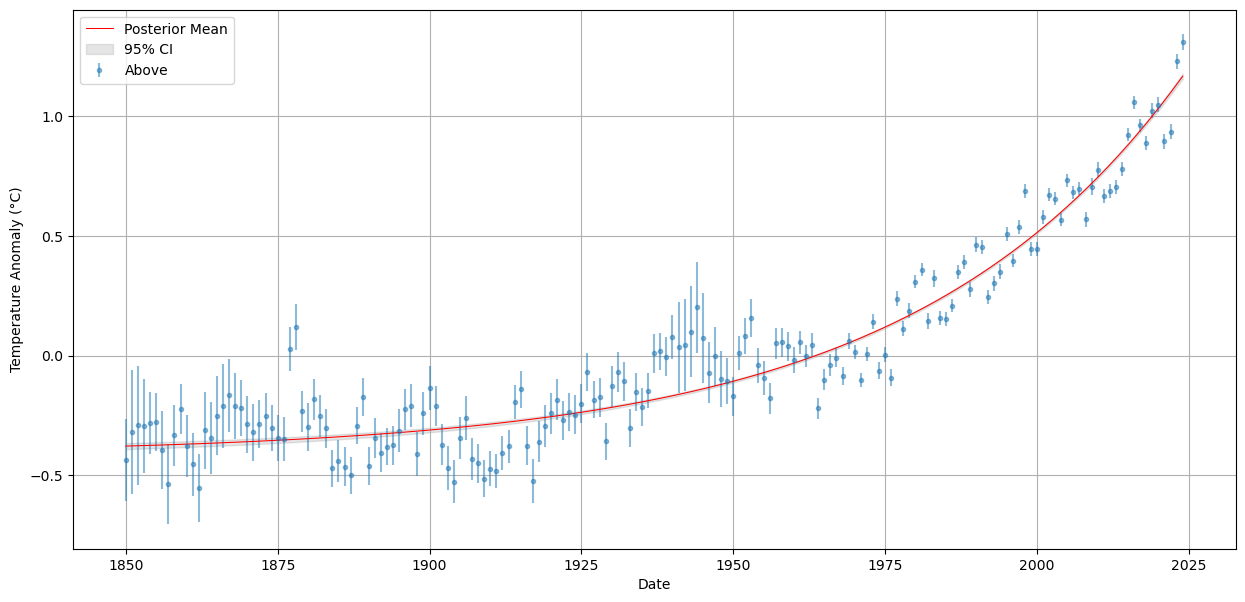

In [64]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min(), df["year"].max(), 100)
band = PredictionBand(year_range)

for params in result_exponential["samples"]:
    q, a, m = params
    band.add(exponential_model(year_range, q, a, m))

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.2)


plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [66]:
# logz
logz_costant = result["logz"]
logz_linear = result_linear["logz"]
logz_exponential = result_exponential["logz"]
print(f"LogZ Constant Model: {logz_costant:.2f}")
print(f"LogZ Linear Model: {logz_linear:.2f}")
print(f"LogZ Exponential Model: {logz_exponential:.2f}")

logz_differences = {
    "Linear vs Constant": logz_linear - logz_costant,
    "Exponential vs Constant": logz_exponential - logz_costant,
    "Exponential vs Linear": logz_exponential - logz_linear,
}

for model_pair, logz_diff in logz_differences.items():
    K = np.exp(logz_diff)
    print(f"LogZ Difference ({model_pair}): {logz_diff:.2f}")
    print(f"Bayes Factor ({model_pair}): {K:.2f}")


LogZ Constant Model: -27561.85
LogZ Linear Model: -6229.31
LogZ Exponential Model: -1331.01
LogZ Difference (Linear vs Constant): 21332.53
Bayes Factor (Linear vs Constant): inf
LogZ Difference (Exponential vs Constant): 26230.84
Bayes Factor (Exponential vs Constant): inf
LogZ Difference (Exponential vs Linear): 4898.31
Bayes Factor (Exponential vs Linear): inf


/tmp/ipykernel_1551/1055960919.py:16: RuntimeWarning: overflow encountered in exp
  K = np.exp(logz_diff)
